# Tremor Severity Classification

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('parsed_dataset.csv')
df.head()

,x,y,z,subject,sequence,sensor,label
0,-9.386824,-2.038941,2.577529,68_male_right,postural,wrist,Essential Tremor
1,-8.502000,0.192353,4.808824,68_male_right,postural,wrist,Essential Tremor
2,-8.502000,0.153882,4.770353,68_male_right,postural,wrist,Essential Tremor
3,-8.694353,0.115412,4.847294,68_male_right,postural,wrist,Essential Tremor
4,-8.540471,0.076941,4.885765,68_male_right,postural,wrist,Essential Tremor


In [3]:
df = df.drop(columns=['subject', 'sequence', 'sensor'])
df.head()

,x,y,z,label
0,-9.386824,-2.038941,2.577529,Essential Tremor
1,-8.502000,0.192353,4.808824,Essential Tremor
2,-8.502000,0.153882,4.770353,Essential Tremor
3,-8.694353,0.115412,4.847294,Essential Tremor
4,-8.540471,0.076941,4.885765,Essential Tremor


In [5]:
df['label'].value_counts()

,count
label,
Healthy Control,49899
Parkinson's Disease,14813
Essential Tremor,3719


In [6]:
df['actual'] = df['label'].map({
    'Healthy Control': 0,
    "Parkinson's Disease": 1,
    'Essential Tremor': 2,
})

df['actual'].value_counts()

,count
actual,
0,49899
1,14813
2,3719


## Normalize and filter

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['x', 'y', 'z']] = scaler.fit_transform(df[['x', 'y', 'z']])

In [8]:
df.head()

,x,y,z,label,actual
0,-2.674750,-0.872822,-3.740989,Essential Tremor,2
1,-2.377961,0.208178,-2.381128,Essential Tremor,2
2,-2.377961,0.189540,-2.404574,Essential Tremor,2
3,-2.442480,0.170902,-2.357683,Essential Tremor,2
4,-2.390865,0.152264,-2.334237,Essential Tremor,2


In [ ]:
df[['x', 'y', 'z']].values

array([[-2.67474978, -0.87282189, -3.7409892 ],
       [-2.37796092,  0.20817801, -2.38112834],
       [-2.37796092,  0.18953988, -2.40457446],
       ...,
       [-0.44238245, -0.77963221,  0.26825442],
       [-0.42947845, -0.74235643,  0.2448083 ],
       [-0.42947845, -0.7237183 ,  0.22136279]], shape=(68431, 3))

In [10]:
def create_windows(df, window_size=300, step_size=150):
    X = []
    y = []

    data = df[['x', 'y', 'z']]
    labels = df['actual']

    for i in range(0, len(data) - window_size + 1, step_size):
        window = data[i : i + window_size]
        X.append(window)
        y.append(labels[i])

    return np.array(X), np.array(y)

In [11]:
X, y = create_windows(df, 187, 93)

X.shape, y.shape

((734, 187, 3), (734,))

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train shape: {X_train.shape}, Train labels shape: {y_train.shape}")
print(f"Test shape: {X_val.shape}, Test labels shape: {y_val.shape}")

Train shape: (587, 187, 3), Train labels shape: (587,)
Test shape: (147, 187, 3), Test labels shape: (147,)


In [13]:
from torch.utils.data import DataLoader, Dataset

class TorchDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TorchDataset(X_train, y_train)
val_ds = TorchDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

In [35]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(3, 32, kernel_size=3, stride=1, padding=2),
            nn.ReLU(inplace=True),

            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),

            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv1d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(256, 5),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CNN().to(device)

model


CNN(
  (features): Sequential(
    (0): Conv1d(3, 32, kernel_size=(3,), stride=(1,), padding=(2,))
    (1): ReLU(inplace=True)
    (2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(2,))
    (3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (6): ReLU(inplace=True)
    (7): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (8): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.2, inplace=False)
    (2): Linear(in_features=256, out_features=5, bias=True)
  )
)

In [14]:
# HYPERPARAMETER

EPOCHS = 100

LR = 0.001

WEIGHT_DECAY = 1e-4

In [36]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = OneCycleLR(optimizer, max_lr=LR, epochs=EPOCHS, steps_per_epoch=len(train_loader), pct_start=0.3)

In [18]:
from sklearn.metrics import accuracy_score

def train_one_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Per batch size
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(all_labels)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, all_preds, all_labels

In [19]:
class EarlyStopping():
  def __init__(self, patience, verbose=False, delta=0, path='checkpoint.pth'):
    self.patience = patience
    self.verbose = verbose
    self.delta = delta
    self.path = path

    self.counter = 0
    self.best_score = None
    self.early_stop = False
    self.val_loss_min = np.inf

  def __call__(self, val_loss, model):
    score = -val_loss

    if self.best_score is None:
      self.best_score = score
      self.save_checkpoint(val_loss, model)

    elif score < self.best_score + self.delta:
      self.counter += 1

      if self.verbose:
        print(f"EarlyStopping counter: {self.counter} out of {self.patience}")

      if self.counter >= self.patience:
        self.early_stop = True

    else:
      self.best_score = score
      self.save_checkpoint(val_loss, model)
      self.counter = 0

  def save_checkpoint(self, val_loss, model):
    if self.verbose:
      print(f"Validation loss decreased from {self.val_loss_min:.6f} to {val_loss:.6f}. Saving model...")

    self.val_loss_min = val_loss
    torch.save(model.state_dict(), self.path)

In [37]:
early_stopping = EarlyStopping(20, verbose=True, path='cnn_classifier.pth')

train_losses = []
train_accs = []
val_losses = []
val_accs = []

all_preds = []
all_labels = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    # Training
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation
    val_loss, val_acc, preds, labels = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    all_preds = preds
    all_labels = labels

    # Early stopping
    early_stopping(val_loss, model)
    # if early_stopping.early_stop:
    #     print("Early stop")
    #     break

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")


Epoch 1/100
----------------------------------------
Validation loss decreased from inf to 1.537773. Saving model...
Train Loss: 1.3946 | Train Acc: 0.5673
Val Loss:   1.5378 | Val Acc:   0.5986

Epoch 2/100
----------------------------------------
Validation loss decreased from 1.537773 to 1.274474. Saving model...
Train Loss: 1.1847 | Train Acc: 0.7359
Val Loss:   1.2745 | Val Acc:   0.7415

Epoch 3/100
----------------------------------------
Validation loss decreased from 1.274474 to 0.970736. Saving model...
Train Loss: 1.0269 | Train Acc: 0.7496
Val Loss:   0.9707 | Val Acc:   0.8231

Epoch 4/100
----------------------------------------
Validation loss decreased from 0.970736 to 0.787342. Saving model...
Train Loss: 0.8785 | Train Acc: 0.7888
Val Loss:   0.7873 | Val Acc:   0.8299

Epoch 5/100
----------------------------------------
Validation loss decreased from 0.787342 to 0.657769. Saving model...
Train Loss: 0.7375 | Train Acc: 0.8007
Val Loss:   0.6578 | Val Acc:   0.8367


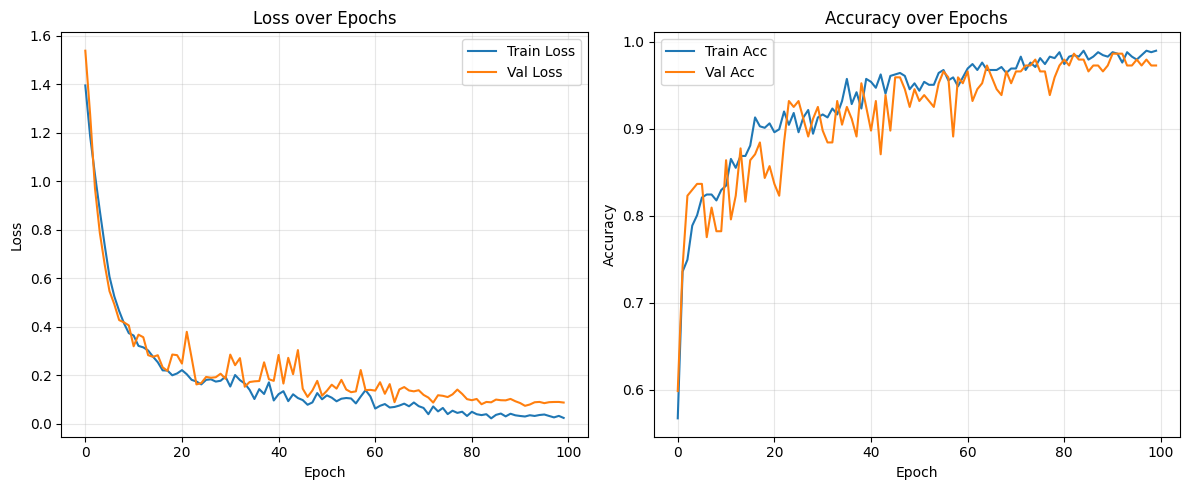

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss over epochs
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy over epochs
axes[1].plot(train_accs, label='Train Acc')
axes[1].plot(val_accs, label='Val Acc')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

          HC       0.99      0.98      0.99       104
          PD       0.92      0.97      0.95        36
          ET       1.00      0.86      0.92         7

    accuracy                           0.97       147
   macro avg       0.97      0.94      0.95       147
weighted avg       0.97      0.97      0.97       147



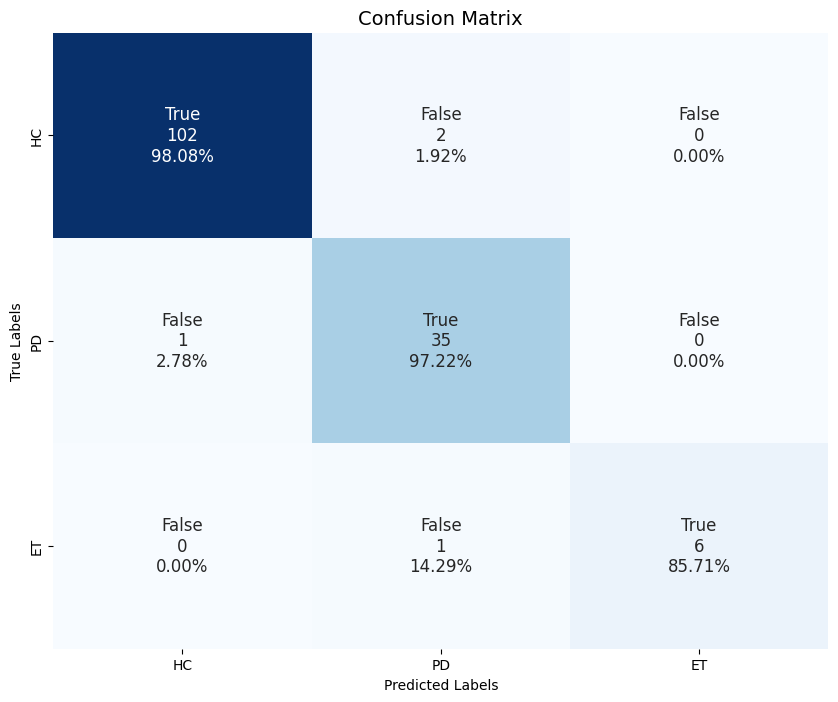

In [39]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

lbls = ['HC', 'PD', 'ET']

report = classification_report(all_labels, all_preds, target_names=lbls)
print(report)

cm = confusion_matrix(all_labels, all_preds, )

cm_sum = np.sum(cm, axis=1, keepdims=True)
cm_perc = cm / cm_sum.astype(float) * 100

# Logic for "True" vs "False" labels
blanks = ["" for i in range(cm.size)]
annot = []
for i in range(len(cm)):
    for j in range(len(cm)):
        status = "True" if i == j else "False"
        annot.append(f"{status}\n{cm[i,j]}\n{cm_perc[i,j]:.2f}%")
annot = np.asarray(annot).reshape(cm.shape)

# 4. Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", cbar=False,
            xticklabels=lbls, yticklabels=lbls,
            annot_kws={"size": 12})

plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Labels", fontsize=10)
plt.ylabel("True Labels", fontsize=10)
plt.show()